You are provided with the Breast Cancer Wisconsin (Original) Dataset from the UCI
Machine Learning Repository. This dataset contains 699 instances with 10 attributes
describing the cellular characteristics of breast biopsies. Perform Exploratory Data
Analysis (EDA). Preprocess the dataset. Convert the target labels from 2 → 0 (Benign)
and 4 → 1 (Malignant). Normalize or standardize features if necessary. Split the dataset
into training (80%) and testing (20%) sets. Implement at least two classification models
such as Logistic Regression, Decision Tree Classifier, Random Forest Classifier, Support
Vector Machine (SVM). Evaluate the models using appropriate performance metrics.
Compare the performance of the models and justify which model is more suitable for
breast cancer classification. 


In [209]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.svm import SVC
from sklearn.impute import KNNImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score,roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import math

In [109]:
breast_cancer = fetch_ucirepo(id = 15)
bc_X = breast_cancer.data.features
bc_y = breast_cancer.data.targets

Displaying the features of the dataset

In [110]:
bc_X

,Clump_thickness,Uniformity_of_cell_size,Uniformity_of_cell_shape,Marginal_adhesion,Single_epithelial_cell_size,Bare_nuclei,Bland_chromatin,Normal_nucleoli,Mitoses
0,5,1,1,1,2,1.0,3,1,1
1,5,4,4,5,7,10.0,3,2,1
2,3,1,1,1,2,2.0,3,1,1
3,6,8,8,1,3,4.0,3,7,1
4,4,1,1,3,2,1.0,3,1,1
...,...,...,...,...,...,...,...,...,...
694,3,1,1,1,3,2.0,1,1,1
695,2,1,1,1,2,1.0,1,1,1
696,5,10,10,3,7,3.0,8,10,2
697,4,8,6,4,3,4.0,10,6,1


Displaying the target variable

In [111]:
bc_y

,Class
0,2
1,2
2,2
3,2
4,2
...,...
694,2
695,2
696,4
697,4


Checking for missing values

In [112]:
bc_X.isnull().sum()

Clump_thickness                 0
Uniformity_of_cell_size         0
Uniformity_of_cell_shape        0
Marginal_adhesion               0
Single_epithelial_cell_size     0
Bare_nuclei                    16
Bland_chromatin                 0
Normal_nucleoli                 0
Mitoses                         0
dtype: int64

The dataset has 16 missing values in the **Bare_nuclei** column.

In [113]:
bc_X.describe()

,Clump_thickness,Uniformity_of_cell_size,Uniformity_of_cell_shape,Marginal_adhesion,Single_epithelial_cell_size,Bare_nuclei,Bland_chromatin,Normal_nucleoli,Mitoses
count,699.000000,699.000000,699.000000,699.000000,699.000000,683.000000,699.000000,699.000000,699.000000
mean,4.417740,3.134478,3.207439,2.806867,3.216023,3.544656,3.437768,2.866953,1.589413
std,2.815741,3.051459,2.971913,2.855379,2.214300,3.643857,2.438364,3.053634,1.715078
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,2.000000,1.000000,1.000000,1.000000,2.000000,1.000000,2.000000,1.000000,1.000000
50%,4.000000,1.000000,1.000000,1.000000,2.000000,1.000000,3.000000,1.000000,1.000000
75%,6.000000,5.000000,5.000000,4.000000,4.000000,6.000000,5.000000,4.000000,1.000000
max,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000


In [114]:
bc_X["Bare_nuclei"].value_counts()

Bare_nuclei
1.0     402
10.0    132
2.0      30
5.0      30
3.0      28
8.0      21
4.0      19
9.0       9
7.0       8
6.0       4
Name: count, dtype: int64

In [115]:
combined = pd.concat([bc_X, bc_y], axis=1)
combined.head()

,Clump_thickness,Uniformity_of_cell_size,Uniformity_of_cell_shape,Marginal_adhesion,Single_epithelial_cell_size,Bare_nuclei,Bland_chromatin,Normal_nucleoli,Mitoses,Class
0,5,1,1,1,2,1.0,3,1,1,2
1,5,4,4,5,7,10.0,3,2,1,2
2,3,1,1,1,2,2.0,3,1,1,2
3,6,8,8,1,3,4.0,3,7,1,2
4,4,1,1,3,2,1.0,3,1,1,2


In [116]:
bc_X[bc_X["Uniformity_of_cell_shape"] == 1]

,Clump_thickness,Uniformity_of_cell_size,Uniformity_of_cell_shape,Marginal_adhesion,Single_epithelial_cell_size,Bare_nuclei,Bland_chromatin,Normal_nucleoli,Mitoses
0,5,1,1,1,2,1.0,3,1,1
2,3,1,1,1,2,2.0,3,1,1
4,4,1,1,3,2,1.0,3,1,1
6,1,1,1,1,2,10.0,3,1,1
8,2,1,1,1,2,1.0,1,1,5
...,...,...,...,...,...,...,...,...,...
690,1,1,1,3,2,1.0,1,1,1
692,3,1,1,1,2,1.0,1,1,1
693,3,1,1,1,2,1.0,2,1,2
694,3,1,1,1,3,2.0,1,1,1


In [75]:
bc_X.loc[bc_X["Bare_nuclei"].isnull()].sort_values(by = ['Mitoses'])

,Clump_thickness,Uniformity_of_cell_size,Uniformity_of_cell_shape,Marginal_adhesion,Single_epithelial_cell_size,Bare_nuclei,Bland_chromatin,Normal_nucleoli,Mitoses
23,8,4,5,1,2,NaN,7,3,1
40,6,6,6,9,6,NaN,7,8,1
139,1,1,1,1,1,NaN,2,1,1
145,1,1,3,1,2,NaN,2,1,1
158,1,1,2,1,3,NaN,1,1,1
164,5,1,1,1,2,NaN,3,1,1
235,3,1,4,1,2,NaN,3,1,1
249,3,1,1,1,2,NaN,3,1,1
275,3,1,3,1,2,NaN,2,1,1
292,8,8,8,1,2,NaN,6,10,1


In [79]:
bc_X.median()

Clump_thickness                4.0
Uniformity_of_cell_size        1.0
Uniformity_of_cell_shape       1.0
Marginal_adhesion              1.0
Single_epithelial_cell_size    2.0
Bare_nuclei                    1.0
Bland_chromatin                3.0
Normal_nucleoli                1.0
Mitoses                        1.0
dtype: float64

Using KNN Imputer to fill the missing values in the **Bare_nuclei** column.

In [117]:
ki = KNNImputer(n_neighbors=5)
imputed_data = pd.DataFrame(ki.fit_transform(bc_X), columns=bc_X.columns)
imputed_data.isnull().sum()


Clump_thickness                0
Uniformity_of_cell_size        0
Uniformity_of_cell_shape       0
Marginal_adhesion              0
Single_epithelial_cell_size    0
Bare_nuclei                    0
Bland_chromatin                0
Normal_nucleoli                0
Mitoses                        0
dtype: int64

In [118]:
imputed_data.describe()

,Clump_thickness,Uniformity_of_cell_size,Uniformity_of_cell_shape,Marginal_adhesion,Single_epithelial_cell_size,Bare_nuclei,Bland_chromatin,Normal_nucleoli,Mitoses
count,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000
mean,4.417740,3.134478,3.207439,2.806867,3.216023,3.528755,3.437768,2.866953,1.589413
std,2.815741,3.051459,2.971913,2.855379,2.214300,3.628479,2.438364,3.053634,1.715078
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,2.000000,1.000000,1.000000,1.000000,2.000000,1.000000,2.000000,1.000000,1.000000
50%,4.000000,1.000000,1.000000,1.000000,2.000000,1.000000,3.000000,1.000000,1.000000
75%,6.000000,5.000000,5.000000,4.000000,4.000000,6.000000,5.000000,4.000000,1.000000
max,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000


Plotting Histograms of features

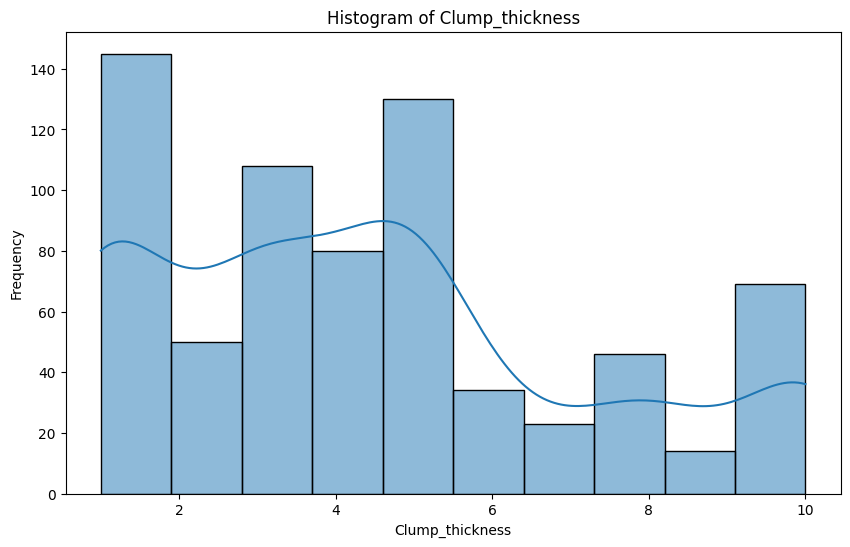

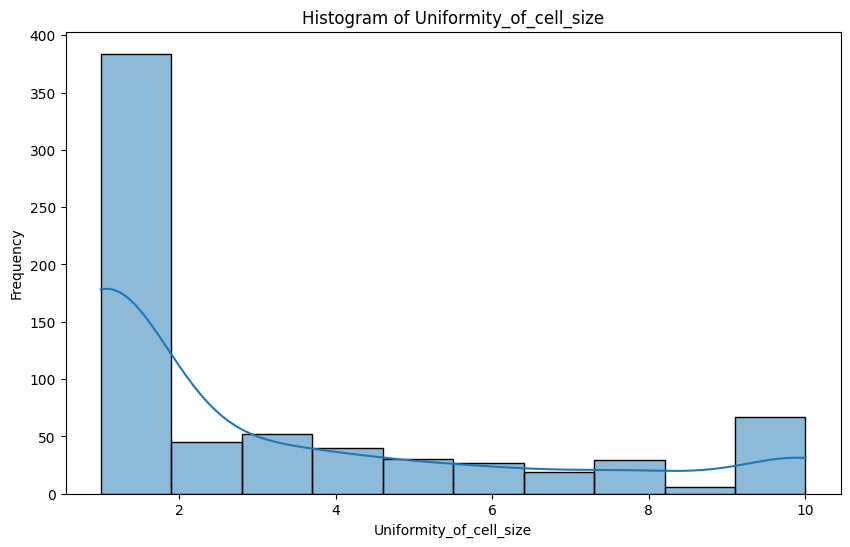

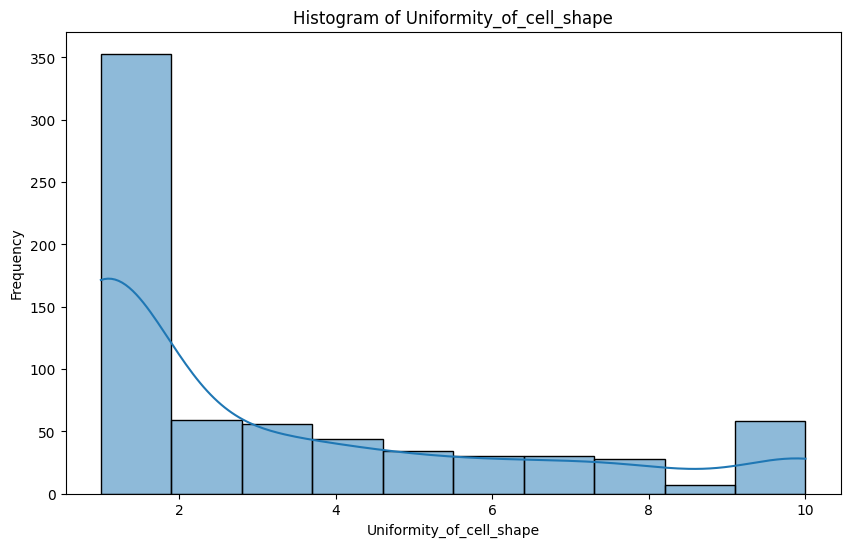

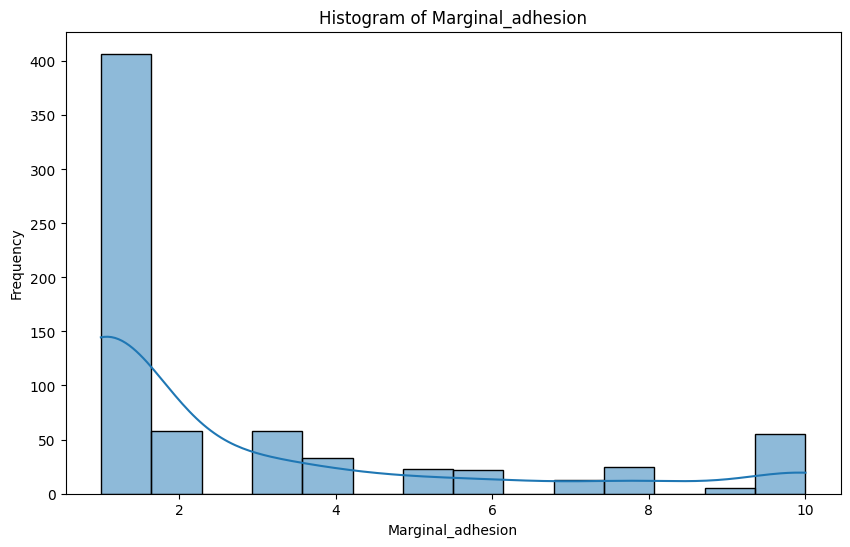

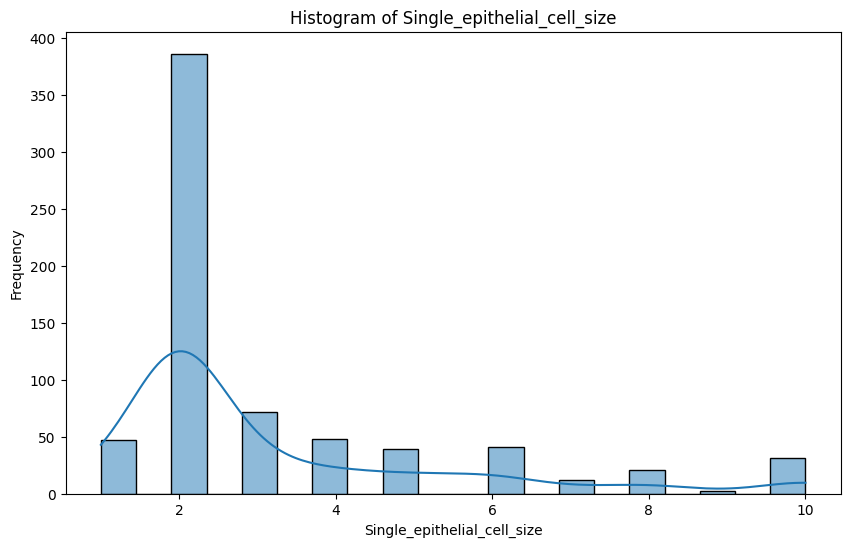

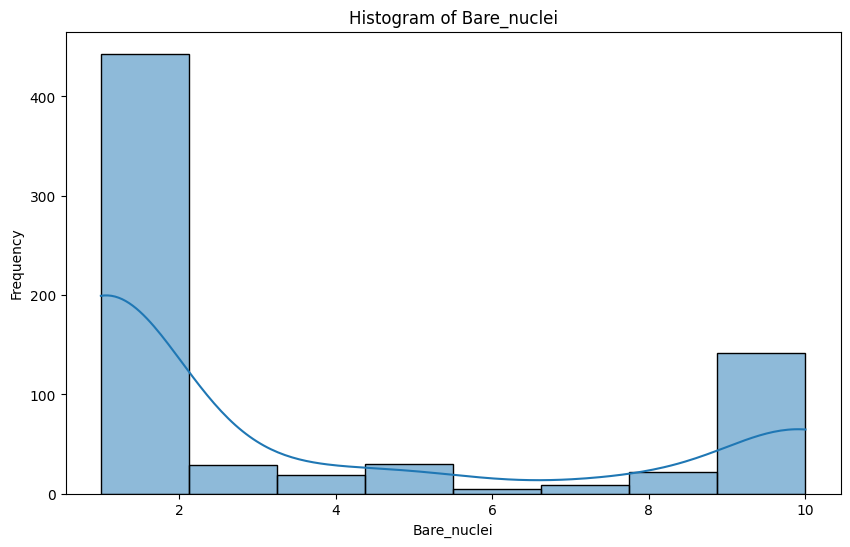

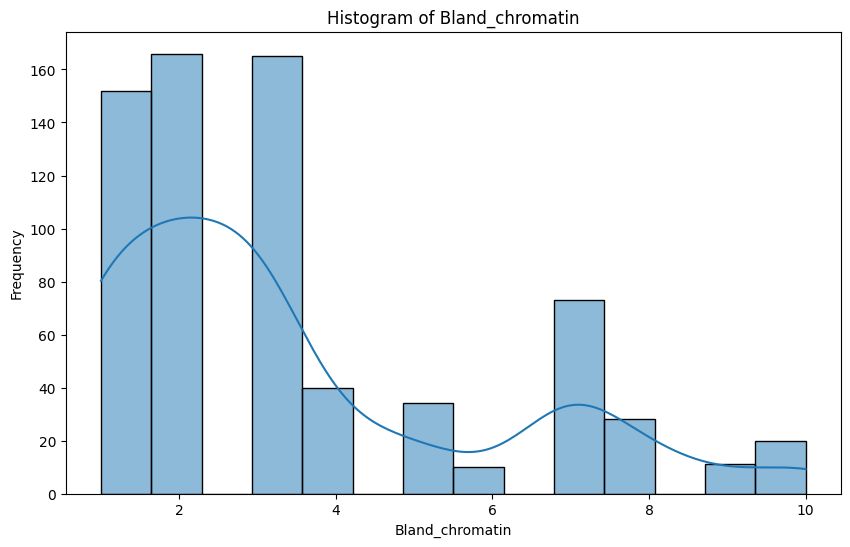

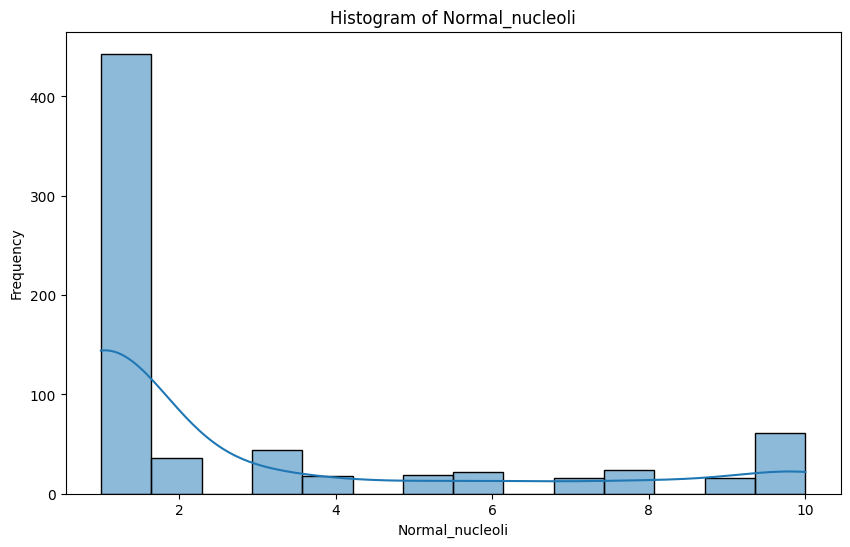

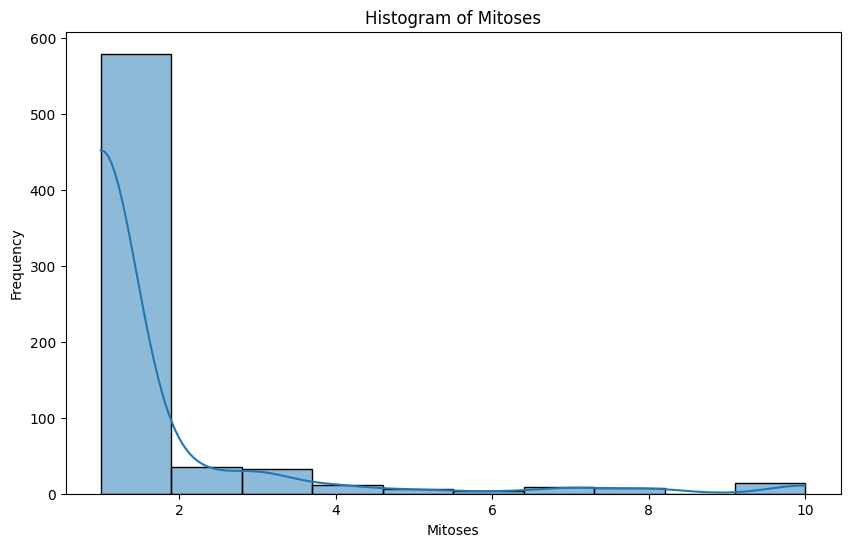

In [119]:
for column in imputed_data.columns[:-1]:
    q1 = imputed_data[column].quantile(0.25)
    q3 = imputed_data[column].quantile(0.75)

    iqr = q3 - q1

    # print(f"iqr for {column}: {iqr}")

    bin_width = 2 * iqr / (len(imputed_data[column]) ** (1/3))
    # print(f"Optimal bin width for {column}: {bin_width}")
    bins = math.ceil((imputed_data[column].max() - imputed_data[column].min()) / bin_width)
    plt.figure(figsize=(10, 6))
    sns.histplot(imputed_data[column], bins=bins, kde=True)
    plt.title(f'Histogram of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(imputed_data["Mitoses"], bins=10, kde=True)
plt.title('Histogram of Mitoses')
plt.xlabel('Mitoses')
plt.ylabel('Frequency')
plt.show()


Creating a correlation heatmap

Text(0.5, 1.0, 'Correlation Matrix of Breast Cancer Dataset')

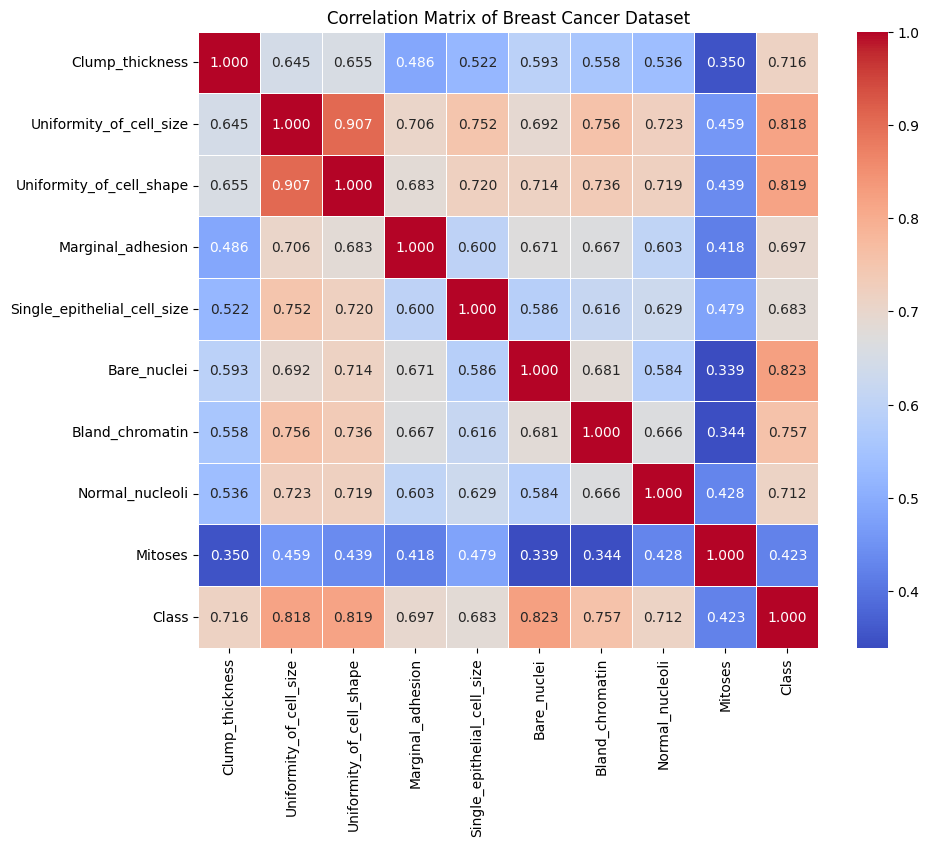

In [120]:
corr = combined.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.3f', linewidths=0.5)
plt.title('Correlation Matrix of Breast Cancer Dataset')

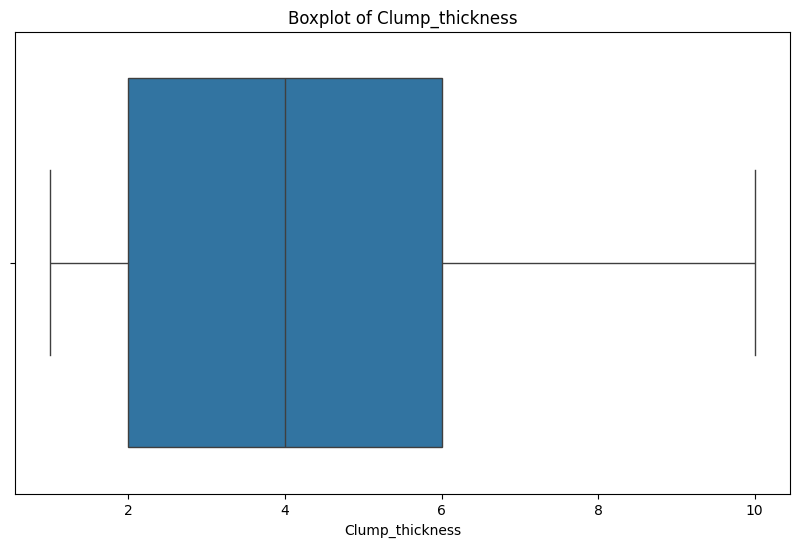

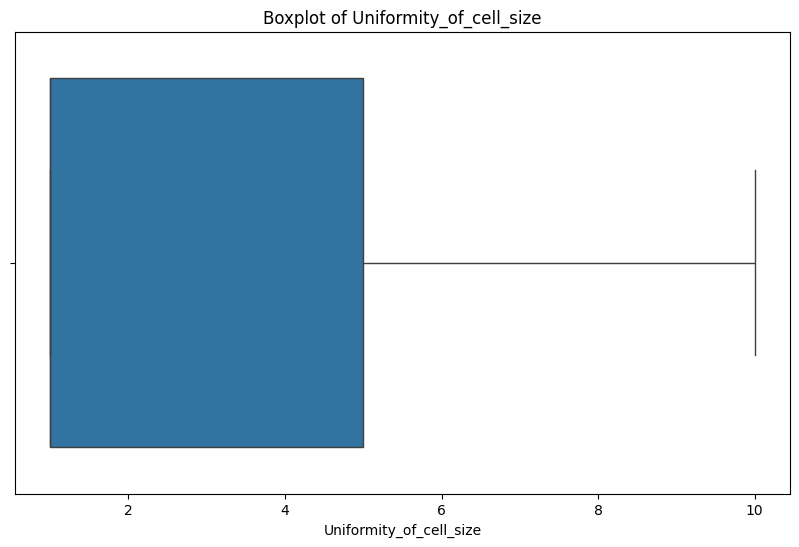

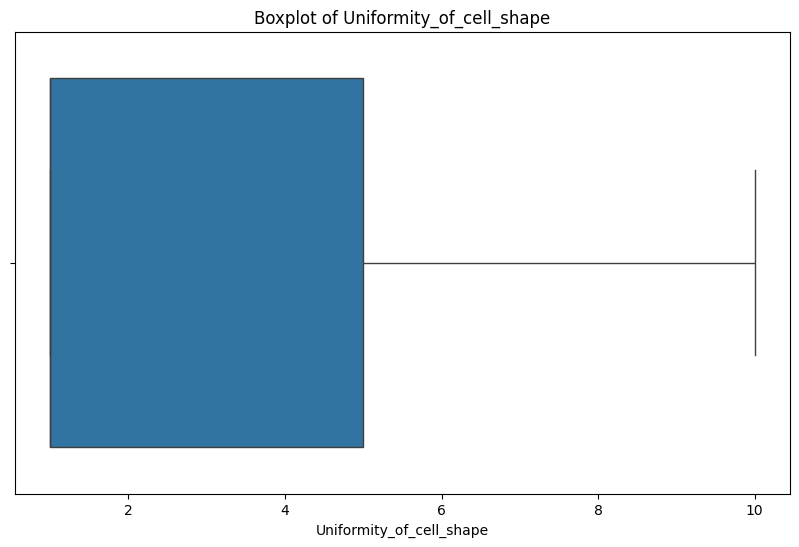

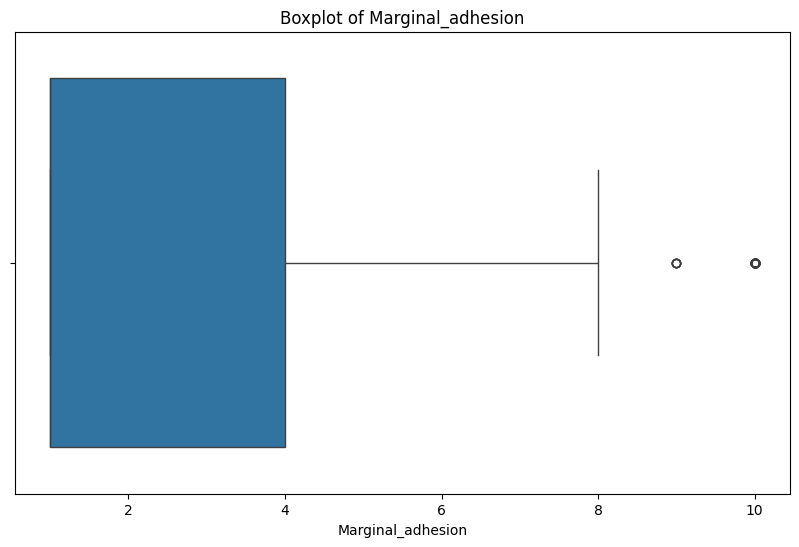

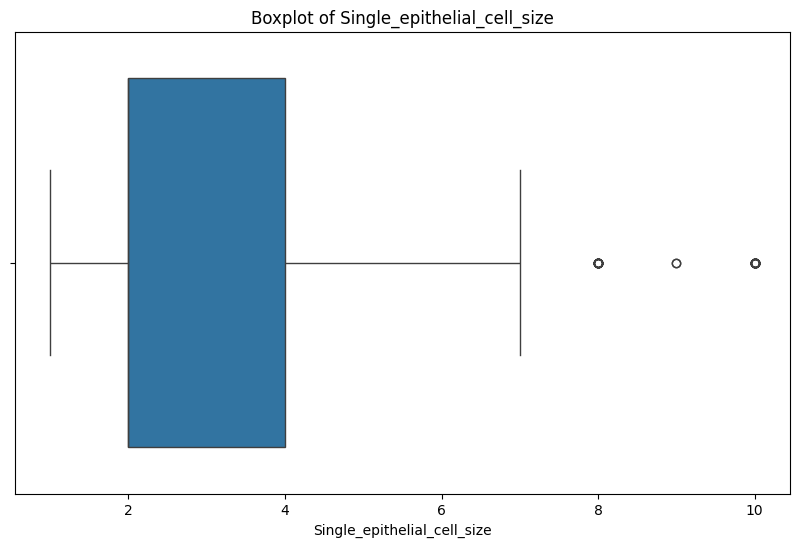

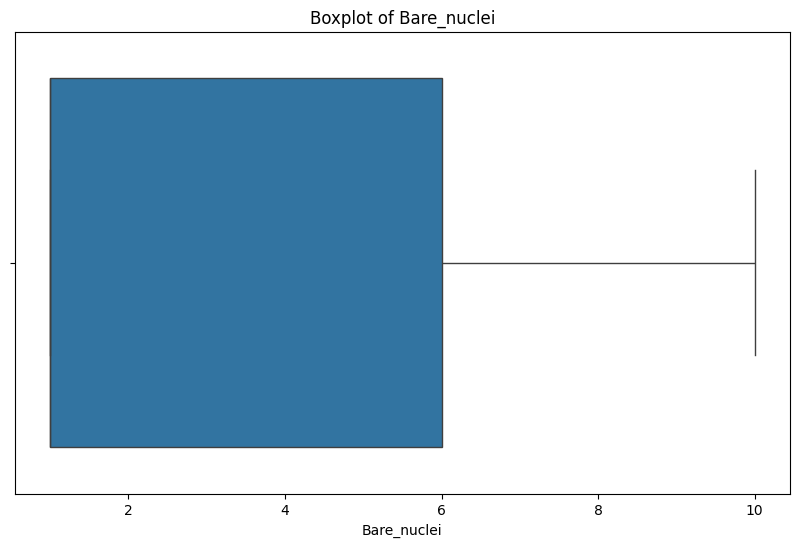

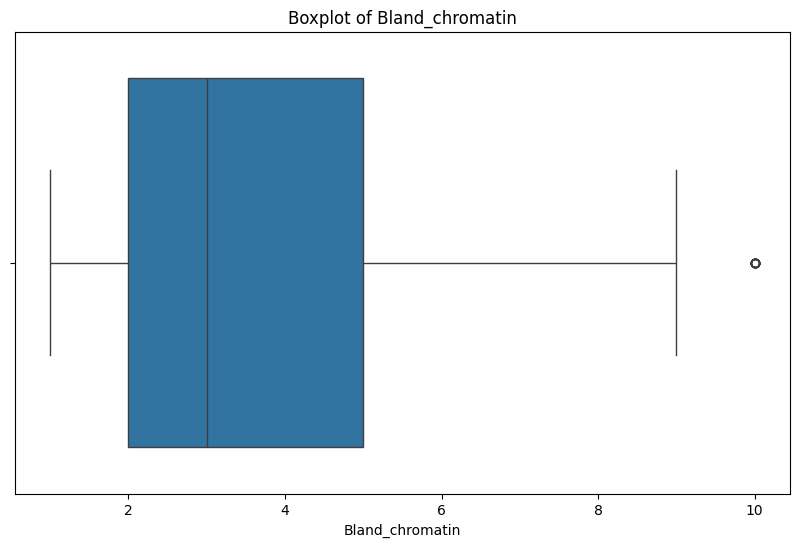

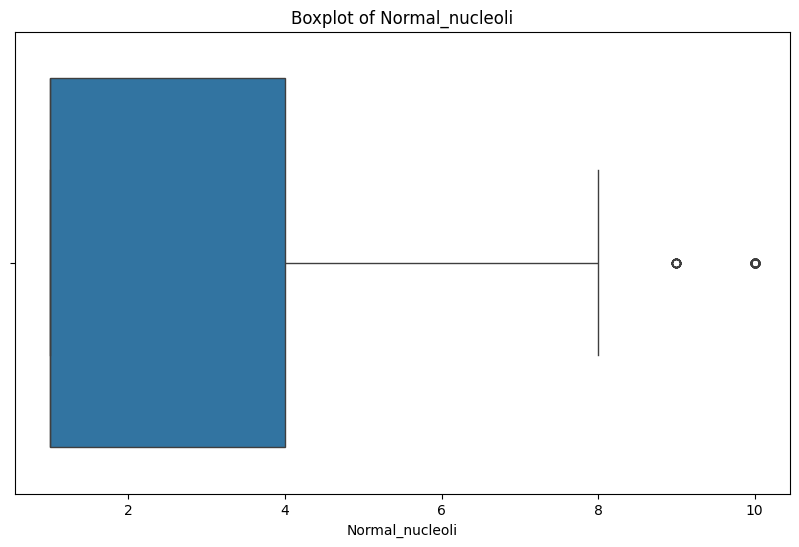

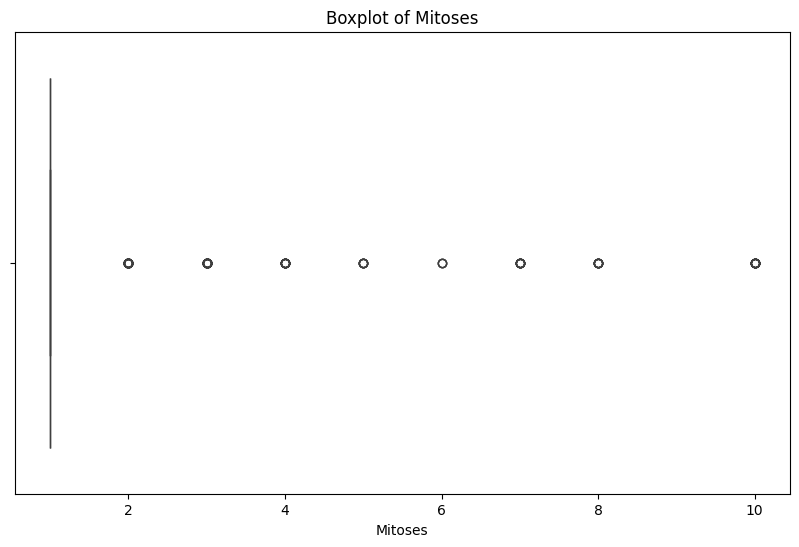

In [101]:
for column in imputed_data.columns:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=imputed_data[column])
    plt.title(f'Boxplot of {column}')
    plt.xlabel(column)
    plt.show()

In [121]:
bc_y = bc_y["Class"].apply(lambda x: 0 if x == 2 else 1)

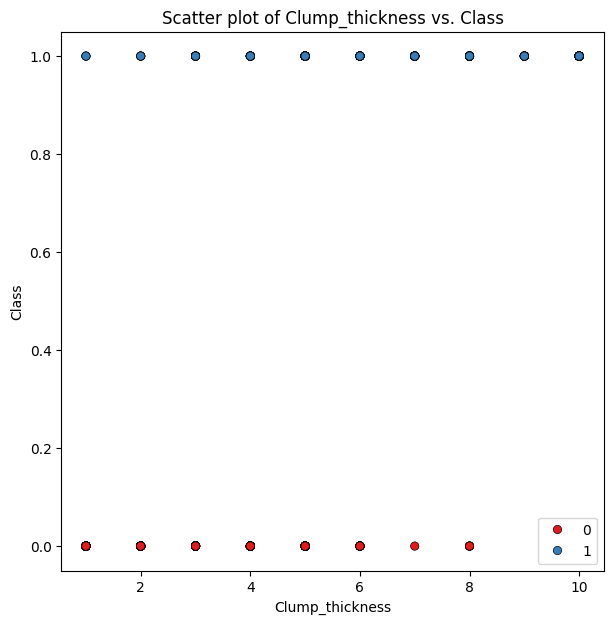

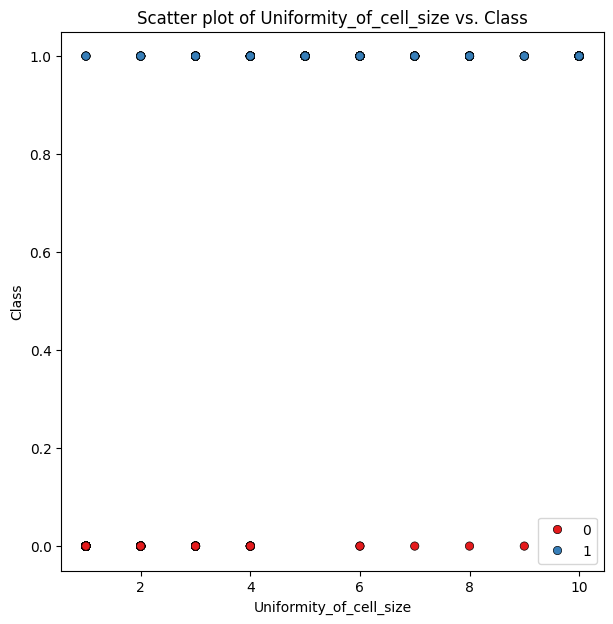

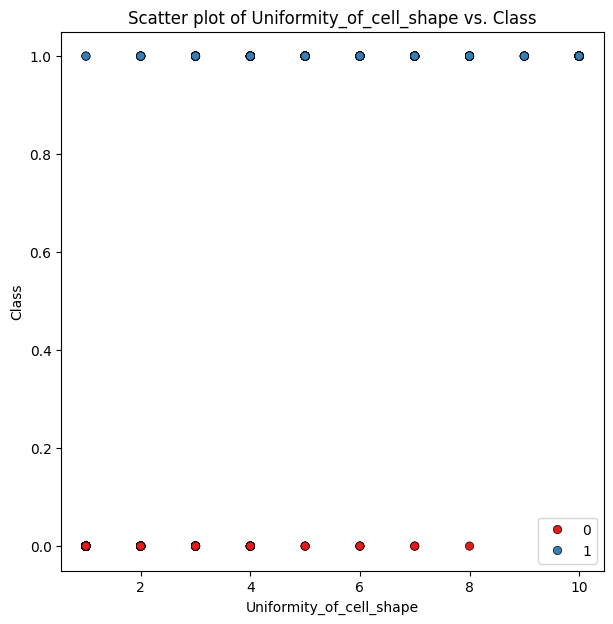

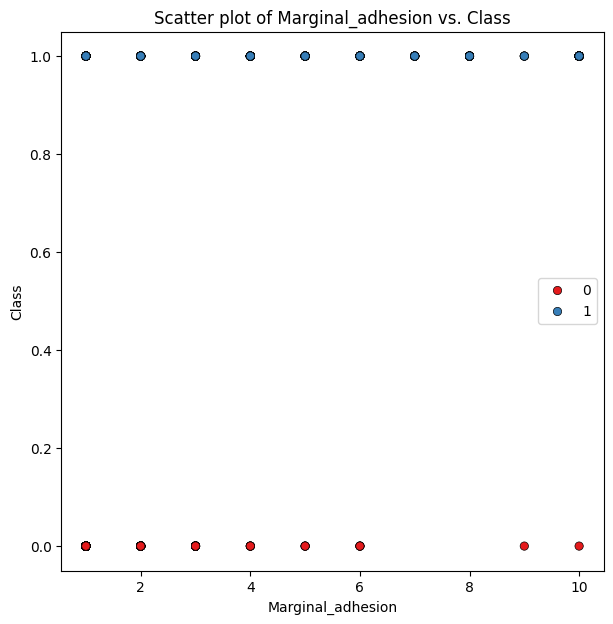

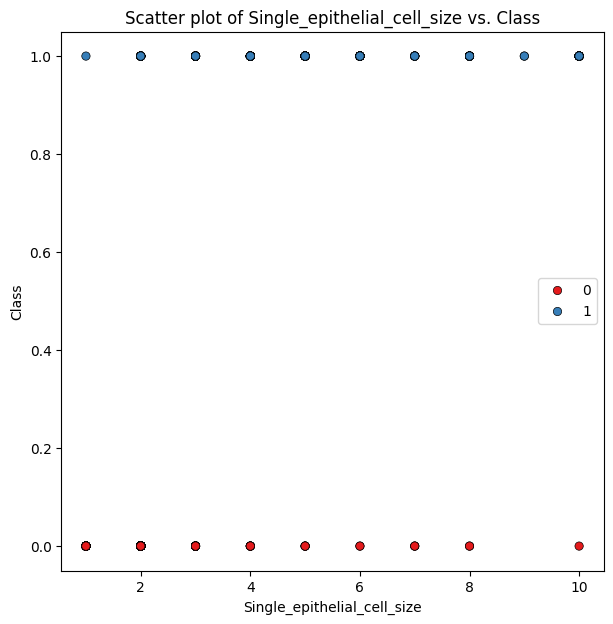

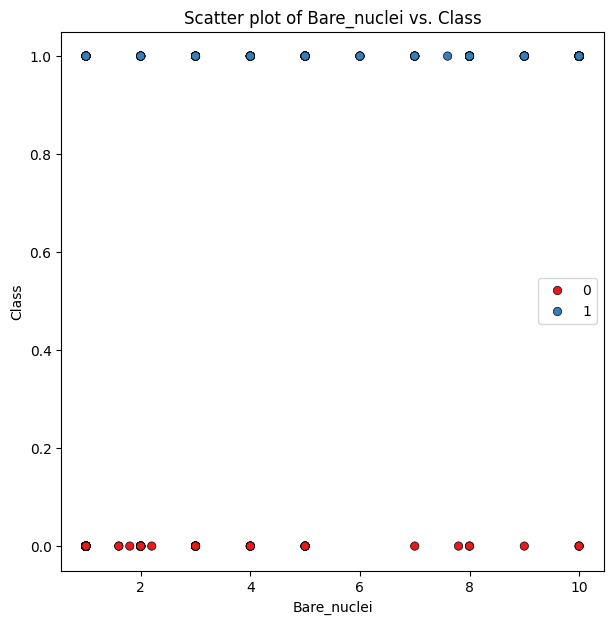

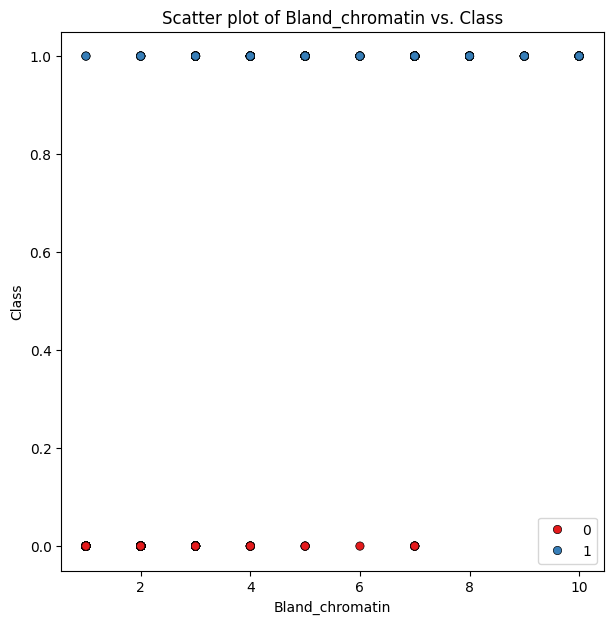

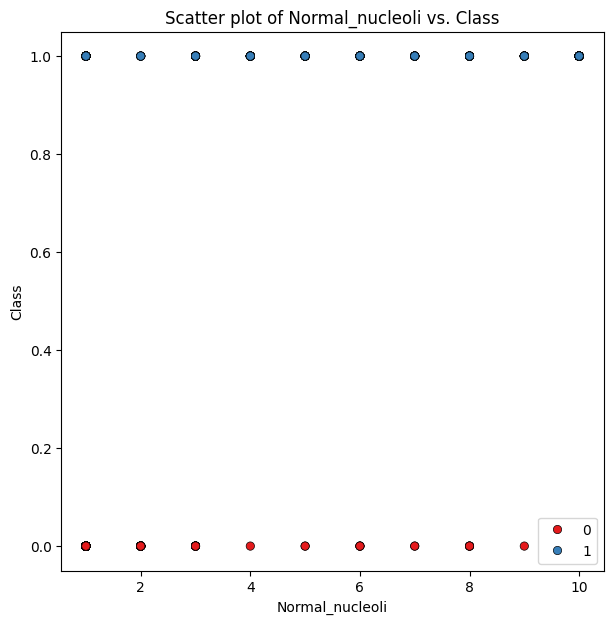

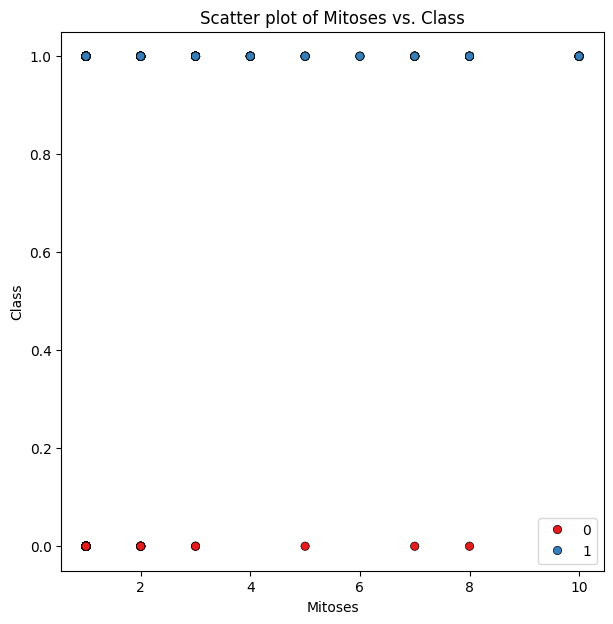

In [210]:
for column in imputed_data.columns:
    plt.figure(figsize=(7,7))
    sns.scatterplot(x = imputed_data[column], y = bc_y.to_numpy().flatten(), edgecolor = 'black', hue = bc_y.to_numpy().flatten(), palette = 'Set1')
    plt.title(f'Scatter plot of {column} vs. Class')
    plt.xlabel(column)
    plt.ylabel('Class')
    plt.show()

Creating train and test splits

In [131]:
X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(imputed_data, bc_y,train_size=0.8, test_size=0.2, random_state=42)

In [177]:
lg_01 = LogisticRegression(solver='newton-cg')


In [178]:
lg_01.fit(X_train_1, y_train_1.to_numpy().flatten())

LogisticRegression(solver='newton-cg')

In [179]:
y_pred_1 = lg_01.predict(X_test_1)

In [180]:
y_pred_1

array([0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0,
       0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0,
       1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0,
       1, 0, 1, 0, 1, 0, 0, 0])

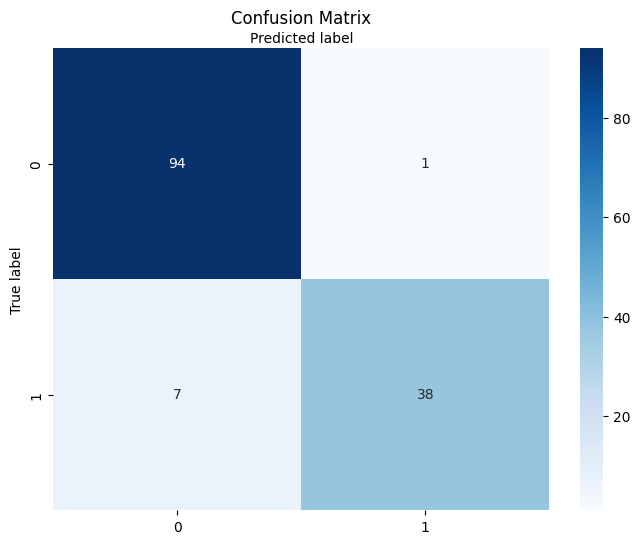

In [184]:
cnf_matrix = confusion_matrix(y_test_1, y_pred_1)
labels = [0,1]

fig, ax = plt.subplots(figsize=(8, 6))
tick_marks = np.arange(len(labels))
plt.xticks(tick_marks, labels)
plt.yticks(tick_marks, labels)
sns.heatmap(cnf_matrix, annot=True, fmt='d', cmap='Blues')
ax.xaxis.set_label_position('top')
plt.title('Confusion Matrix')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

In [185]:
target_names = ['Benign', 'Malignant']
print(classification_report(y_test_1, y_pred_1, target_names=target_names))
print(f"Accuracy: {accuracy_score(y_test_1, y_pred_1)}")

              precision    recall  f1-score   support

      Benign       0.93      0.99      0.96        95
   Malignant       0.97      0.84      0.90        45

    accuracy                           0.94       140
   macro avg       0.95      0.92      0.93       140
weighted avg       0.94      0.94      0.94       140

Accuracy: 0.9428571428571428


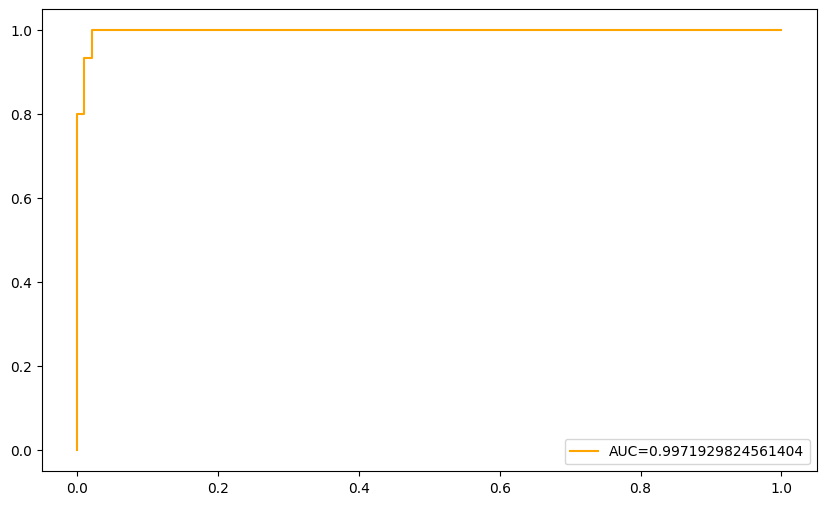

In [193]:
y_pred_1_proba = lg_01.predict_proba(X_test_1)[::, 1]
fpr, tpr, _ = roc_curve(y_test_1,  y_pred_1_proba)
auc = roc_auc_score(y_test_1, y_pred_1_proba)
plt.figure(figsize=(10, 6))
plt.plot(fpr,tpr,label="AUC="+str(auc),color='orange')
plt.legend(loc = 4)
plt.show()

Creating an SVM for classification

In [222]:
svm_01 = SVC(kernel='linear', probability=True)

In [223]:
svm_01.fit(X_train_1, y_train_1.to_numpy().flatten())

SVC(kernel='linear', probability=True)

In [224]:
y_pred_2 = svm_01.predict(X_test_1)

In [225]:
target_names = ['Benign', 'Malignant']
print(classification_report(y_test_1, y_pred_2, target_names=target_names))
print(f"Accuracy: {accuracy_score(y_test_1, y_pred_2)}")

              precision    recall  f1-score   support

      Benign       0.97      0.99      0.98        95
   Malignant       0.98      0.93      0.95        45

    accuracy                           0.97       140
   macro avg       0.97      0.96      0.97       140
weighted avg       0.97      0.97      0.97       140

Accuracy: 0.9714285714285714


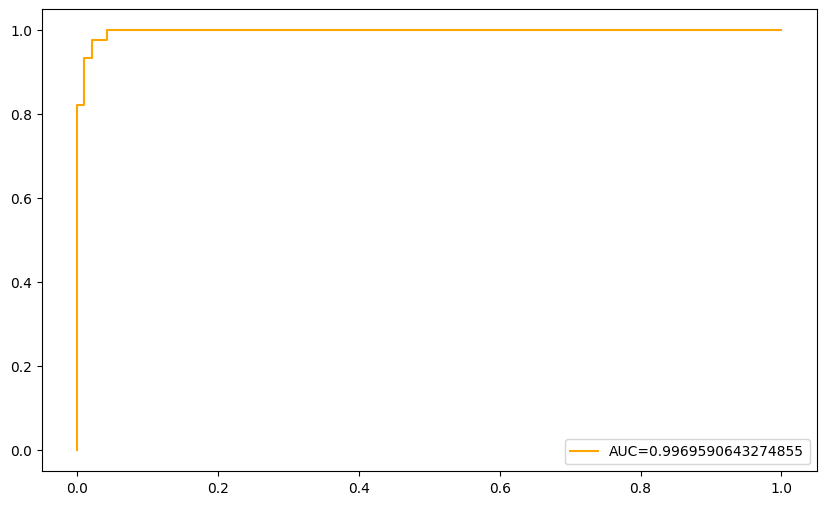

In [226]:
y_pred_2_proba = svm_01.predict_proba(X_test_1)[::, 1]
fpr1, tpr1, _ = roc_curve(y_test_1,  y_pred_2_proba)
auc1 = roc_auc_score(y_test_1, y_pred_2_proba)
plt.figure(figsize=(10, 6))
plt.plot(fpr1,tpr1,label="AUC="+str(auc1),color='orange')
plt.legend(loc = 4)
plt.show()